In [ ]:
import geopandas as gpd
from pathlib import Path

join_datasets = False
excluded_samplers = ['probensing', 'dani', 'portatil', 'pablosanz']

points_gdf = gpd.read_file(r"C:\Users\dani\QField\cloud\Weitec__Muestreo_SMT\Marcas.gpkg").to_crs("EPSG:32630")
area_gdf = gpd.read_file(r"C:\Users\dani\QField\cloud\Weitec__Muestreo_SMT\Marcas_area.gpkg").to_crs(points_gdf.crs)
parcelario_gdf = gpd.read_file(r"C:\Users\dani\QField\cloud\Weitec__Muestreo_Compartido\Parcelario.geojson").to_crs(points_gdf.crs)

if join_datasets:
    points_intern_gdf =  gpd.read_file(r"C:\Users\dani\QField\cloud\Weitec__Muestreo_Compartido\Marcas.gpkg").to_crs(points_gdf.crs)
    area_intern_gdf = gpd.read_file(r"C:\Users\dani\QField\cloud\Weitec__Muestreo_Compartido\Marcas_area.gpkg").to_crs(points_gdf.crs)


out_folder = Path(r"C:\Users\dani\Downloads")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

palette = {
    0: "#283F50",
    1: "#6ea3cc",
    2: '#f1c40f',
    3: "#bb2616"}

AREA_POR_ARBOL = 22 #m2
FACTOR_INCLUSION = 0.25 #el porcentaje de árboles que contamos como válidos

if join_datasets:
    area_gdf = pd.concat([area_gdf, area_intern_gdf]).reset_index()
    points_gdf = pd.concat([points_gdf, points_intern_gdf]).reset_index()

area_gdf['n_samples'] = (area_gdf.geometry.area*FACTOR_INCLUSION/AREA_POR_ARBOL).round().astype(int)
points_gdf['n_samples'] =1

gdf = pd.concat([area_gdf, points_gdf]).reset_index(drop=True)
gdf = gdf[~gdf['user_register'].isin(excluded_samplers)]
gdf.columns

Index(['comments', 'datetime', 'severity', 'id_unique', 'user_register',
       'hide', 'title', 'maps_link', 'position_source', 'horizontal_accuracy',
       'position_quality', 'validated', 'validated_comment', 'validated_at',
       'validated_by', 'validated_correct', 'title_second', 'geometry',
       'n_samples'],
      dtype='object')

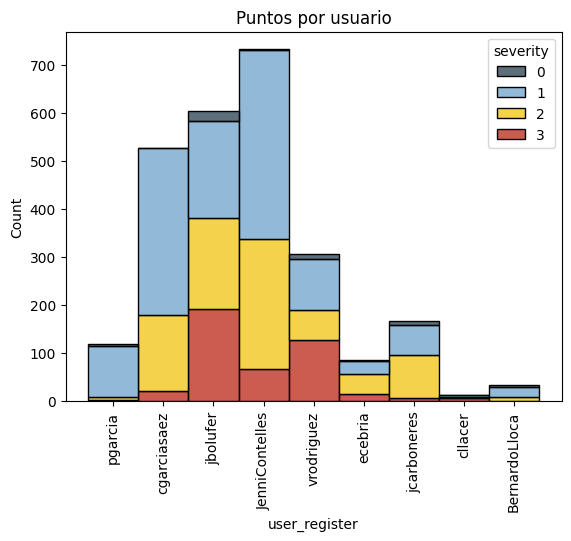

In [12]:
ax = sns.histplot(x='user_register', hue='severity', data=gdf, multiple='stack', palette=palette, weights='n_samples')
plt.xticks(rotation=90)
plt.title('Puntos por usuario')
plt.savefig(out_folder/'user.png', bbox_inches='tight')

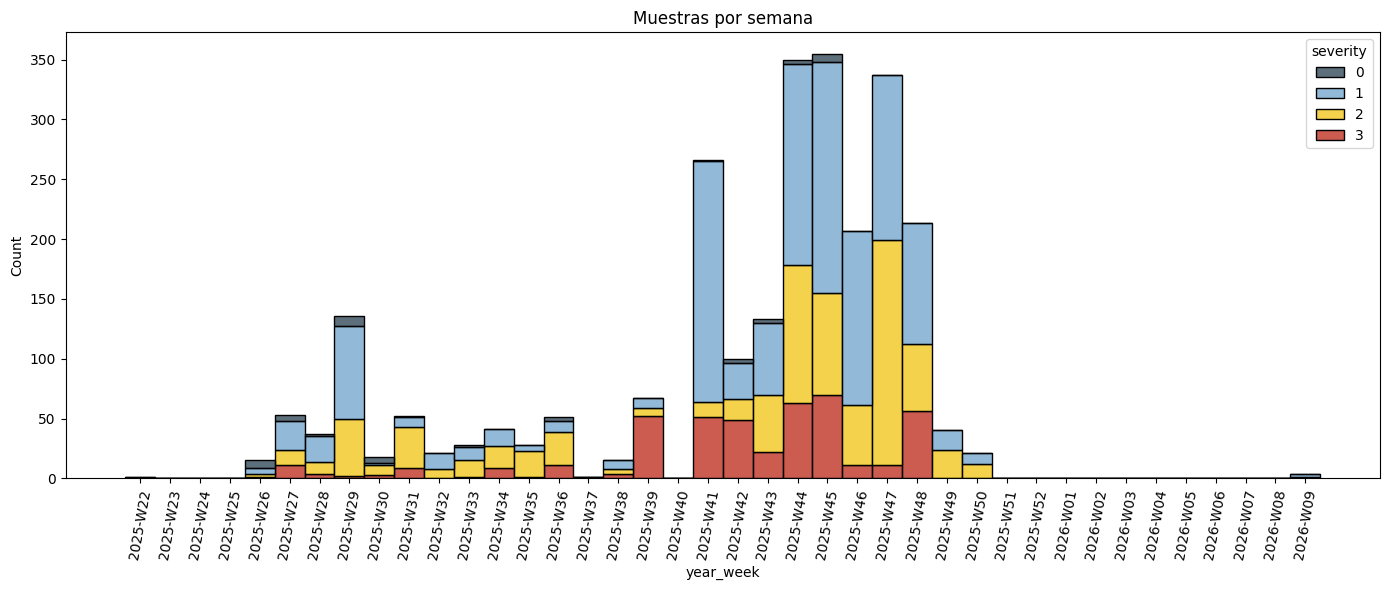

In [ ]:
week_gdf = gdf.copy()
week_gdf['week'] = week_gdf['datetime'].dt.isocalendar().week
week_gdf['year'] = week_gdf['datetime'].dt.isocalendar().year

# Crear columna año-semana
week_gdf['year_week'] = (week_gdf['datetime'].dt.strftime('%G-W%V'))

agg = (week_gdf.groupby(['year_week', 'severity'], as_index=False).agg({"n_samples": "sum"}))

# Rango desde la primera hasta la última semana real
all_weeks = pd.date_range(
    start=week_gdf['datetime'].min(),
    end=week_gdf['datetime'].max(),
    freq='W-MON'  # semanas comenzando el lunes
)
# Convertimos a formato year-week
all_year_weeks = all_weeks.strftime('%G-W%V')
all_index = pd.MultiIndex.from_product(
    [all_year_weeks, agg['severity'].unique()],
    names=['year_week', 'severity']
)
agg_full = agg.set_index(['year_week', 'severity']).reindex(all_index).reset_index()

# Rellenar semanas sin muestras con 0
agg_full['n_samples'] = agg_full['n_samples'].fillna(0)

# Histplot con hue y pesos
plt.figure(figsize=(14, 6))

ax = sns.histplot(
    data=agg_full,
    x="year_week",
    hue="severity",
    weights="n_samples",
    multiple="stack",
    palette=palette,
    discrete=True
)

plt.xticks(rotation=80)
plt.title("Muestras por semana")
plt.tight_layout()
plt.savefig(out_folder/'date.png')


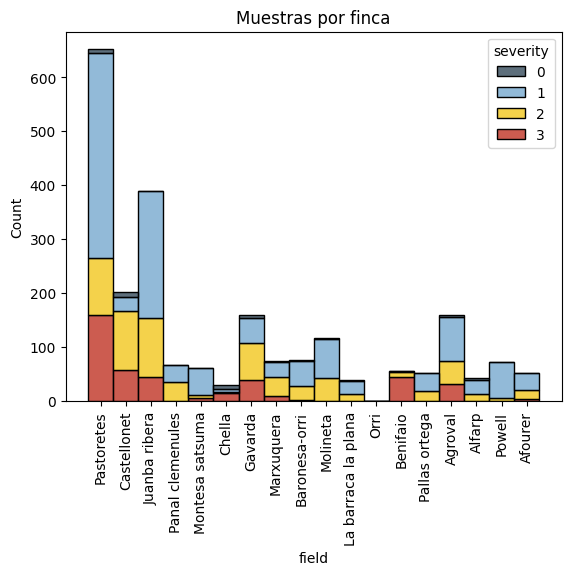

In [22]:
puntos_poligonos_gdf = gpd.sjoin(gdf, parcelario_gdf, how="left").reset_index(drop=True)

ax = sns.histplot(x='field', hue='severity', weights='n_samples', data=puntos_poligonos_gdf, multiple='stack', palette=palette)
plt.xticks(rotation=90)
plt.title('Muestras por finca')
plt.savefig(out_folder/'field.png', bbox_inches='tight')

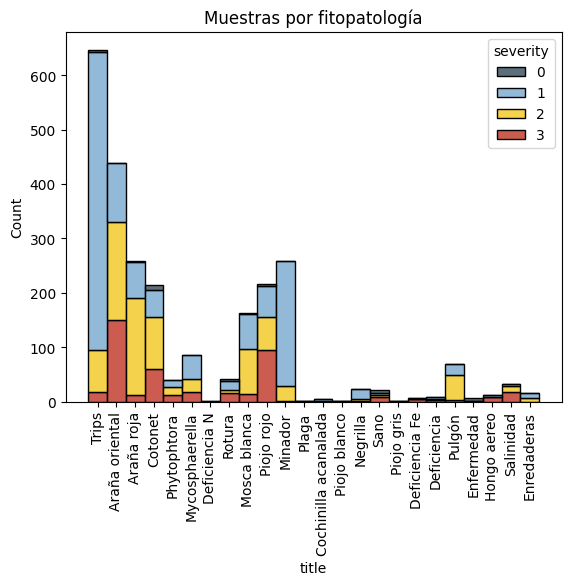

In [30]:
ax = sns.histplot(x='title', hue='severity',weights='n_samples', data=gdf, multiple='stack', palette=palette)
plt.xticks(rotation=90)
plt.title('Muestras por fitopatología')
plt.savefig(out_folder/'phytopatology.png', bbox_inches='tight')

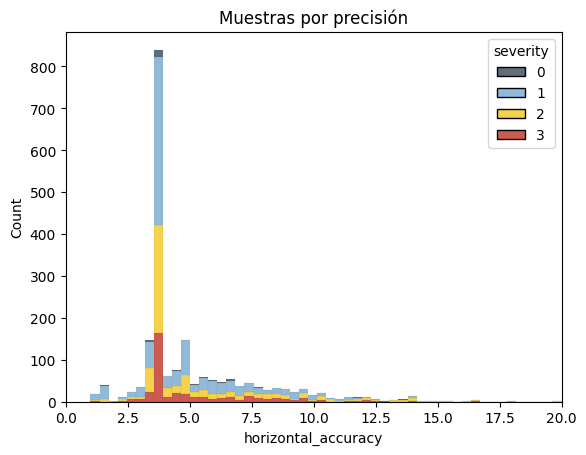

In [23]:
ax = sns.histplot(x='horizontal_accuracy', hue='severity', data=gdf, multiple='stack', palette=palette)
ax.set_xlim(right=20, left=0)
plt.title('Muestras por precisión')
plt.savefig(out_folder/'accuracy.png')

In [ ]:
severity_group = gdf.groupby('severity')['n_samples'].sum()

plt.pie(severity_group, labels=severity_group.index, autopct='%1.1f%%', shadow=True, colors=palette.values())
plt.title('Muestras por severidad')
plt.savefig(out_folder/'severity.png')

In [32]:
join_gdf = gdf.sjoin(parcelario_gdf, how='left', predicate='intersects')
join_gdf.groupby(['title'])['n_samples'].sum()

title
Araña oriental          438
Araña roja              258
Cochinilla acanalada      5
Cotonet                 214
Deficiencia               9
Deficiencia Fe            7
Deficiencia N             1
Enfermedad                6
Enredaderas              15
Hongo aereo              12
Minador                 259
Mosca blanca            163
Mycosphaerella           86
Negrilla                 23
Phytophtora              39
Piojo blanco              1
Piojo gris                2
Piojo rojo              217
Plaga                     2
Pulgón                   69
Rotura                   41
Salinidad                32
Sano                     21
Trips                   647
Name: n_samples, dtype: int64

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)

join_gdf = gdf.sjoin(parcelario_gdf, how='left', predicate='intersects')
join_gdf.groupby(['crop', 'title'])['n_samples'].sum()

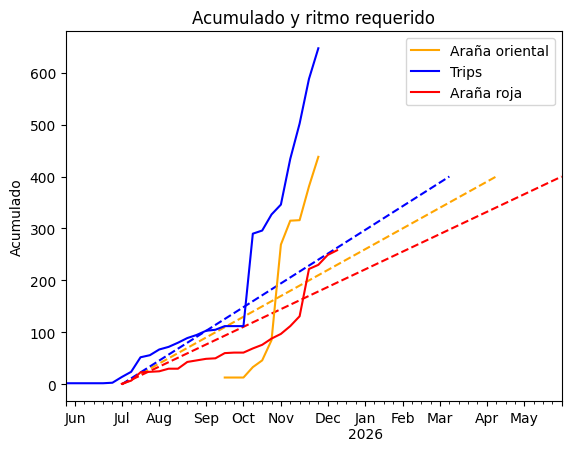

In [29]:
import numpy as np
from matplotlib import pyplot as plt

acumulado_fin = 400
phytopathology_list = [{'phytopathology':'Araña oriental',
                        'init_week': 26,
                        'end_week': 15,
                        'color':'orange'},
                        {'phytopathology':'Trips',
                        'init_week': 26,
                        'end_week': 10,
                        'color':'blue'},
                        {'phytopathology':'Araña roja',
                        'init_week': 26,
                        'end_week': 22,
                        'color':'red'}]

def generate_weeks(init_year, init_week, end_year, end_week):
    # Crear fechas de inicio y fin
    fecha_inicio = pd.to_datetime(f'{init_year}-W{init_week:02d}-1', format='%Y-W%W-%w')
    fecha_fin = pd.to_datetime(f'{end_year}-W{end_week:02d}-1', format='%Y-W%W-%w')
    return pd.date_range(start=fecha_inicio, end=fecha_fin, freq='W')

#crear una linea de puntos
fig, ax = plt.subplots()
for p in phytopathology_list:
    weeks = generate_weeks(2025, p['init_week'], 2026, p['end_week'])
    line_df = pd.DataFrame(
        {'week': weeks,
        'optimo': np.linspace(0, acumulado_fin, len(weeks))}
    )
    line = line_df.plot(x='week', y='optimo',linestyle='--',color=p['color'], ax=ax)
    line.legend_=None

for p in phytopathology_list:
    #plotear n_samples acumulado
    p_df = pd.DataFrame(gdf[gdf['title'] == p['phytopathology']]).sort_values(by='datetime')
    p_group = p_df.groupby(pd.Grouper(key='datetime', freq='W-MON'))['n_samples'].sum().reset_index()
    p_group['acc_sum'] = p_group['n_samples'].cumsum()
    p_group.plot(x='datetime', y='acc_sum', ax=ax, label=p['phytopathology'], color=p['color'])

plt.title('Acumulado y ritmo requerido')
plt.xlabel('')
plt.ylabel('Acumulado')

plt.savefig(out_folder/'samplers_kpi.png')